In [ ]:
%pip install numpy
%pip install pandas
%pip install scikit-learn
%pip install annoy
%pip install fastdtw

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans
from annoy import AnnoyIndex
from scipy.stats import spearmanr

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np, random

In [ ]:
SEED = 42 # For reproducibility
np.random.seed(SEED); random.seed(SEED)

**1. Loading Datasets and first inspection**

2 datasets related to healthcare data are used for this project.
1. Wisconsin Breast Cancer Dataset, https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
2. MIMIC-III Clinical Dataset, https://physionet.org/content/mimiciii/1.4/

These datasets act as similar healthcare datasets that will be used for testing different methods of Similarity Search for SC4020 Data Analytics & Mining project.

Breast cancer dataset is used for a controlled, higher-dimensional case and MIMIC is used for large scale, lower-dimensional dataset. This allow us to evaluate similarity search methods across datasets with contrasting feature sets and sample dimensions.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

base_path = Path("/content/drive/MyDrive/RA")             # Change if necessary
mimic_data = pd.read_csv(base_path / "mimic_pivoted.csv")
breastcancer_data = pd.read_csv(base_path / "BreastCancerData.csv")


In [ ]:
summary = pd.DataFrame({
    "Dataset": ["Breast Cancer", "MIMIC-III"],
    "Samples": [breastcancer_data.shape[0], mimic_data.shape[0]],
    "Features": [breastcancer_data.shape[1], mimic_data.shape[1]]
})
summary

,Dataset,Samples,Features
0,Breast Cancer,569,33
1,MIMIC-III,287594,8


#Wisconsin Breast Cancer Dataset

The Breast Cancer Wisconsin (Diagnostic) dataset is clean, small and well-labelled. It will serve as best case scenario for clean data with minimal clean up for similarity search.

**Preprocessing**

It contains 569 samples, 30 numeric features (mean, SE, worst of radius, texture, smoothness, etc.)

Diagnosis 'M' represents 'Malignant' and 'B' represents 'Benign'. This has been encoded to {'M': 1, 'B': 0}

The data has also be standardised by using Standardscaler() to ensure all features are on the same scale and carry equal weight to the distance calculations.

For Wisconsin Breast Cancer Dataset, the similarity search query will be on Feature-based similarity (Patients with similar tumor attributes)

In [ ]:
breastcancer_data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
list(breastcancer_data)

['id',
 'diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst',
 'Unnamed: 32']

In [ ]:
# Removing empty values in "Unnamed: 32" and removing unnecessary "id"
if "id" in breastcancer_data.columns:
    breastcancer_data = breastcancer_data.drop(columns=["id"])
if "Unnamed: 32" in breastcancer_data.columns:
    breastcancer_data = breastcancer_data.drop(columns=["Unnamed: 32"])

In [ ]:
# The list of discrete columns
breastcancer_data_discrete_columns = [
    'diagnosis',
]

In [ ]:
# Encoding discrete columns to binary
breastcancer_data['diagnosis'] = breastcancer_data['diagnosis'].map({'M':1, 'B':0})

print(breastcancer_data['diagnosis'].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [ ]:
# Splitting data into features (X) and the target variable (y), which is the diagnosis
y = breastcancer_data['diagnosis'].astype(int).to_numpy()  # 1=M, 0=B
X = breastcancer_data.drop(columns=['diagnosis']).to_numpy(dtype=float)

In [ ]:
# Standard scaler for scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Exploratory Data Analysis



In [ ]:
print(breastcancer_data.info())
print(breastcancer_data.describe().T)

# Class balance
print(breastcancer_data['diagnosis'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

/tmp/ipython-input-3678582959.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=breastcancer_data, palette="coolwarm")


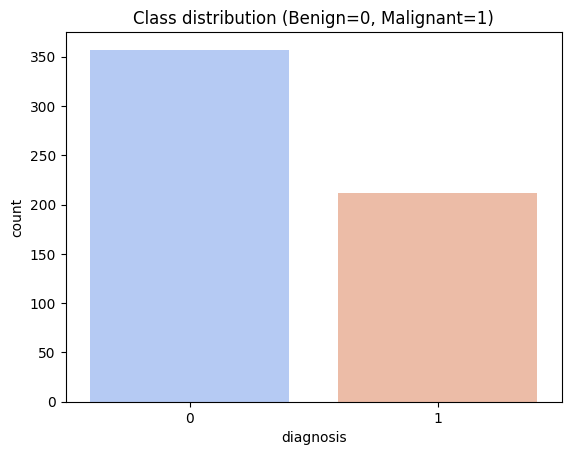

In [ ]:
sns.countplot(x='diagnosis', data=breastcancer_data, palette="coolwarm")
plt.title("Class distribution (Benign=0, Malignant=1)")
plt.show()

Here the dataset shows imbalanced class distribution of benign and malignant class. Benign is around twice the amount of malignant data points.

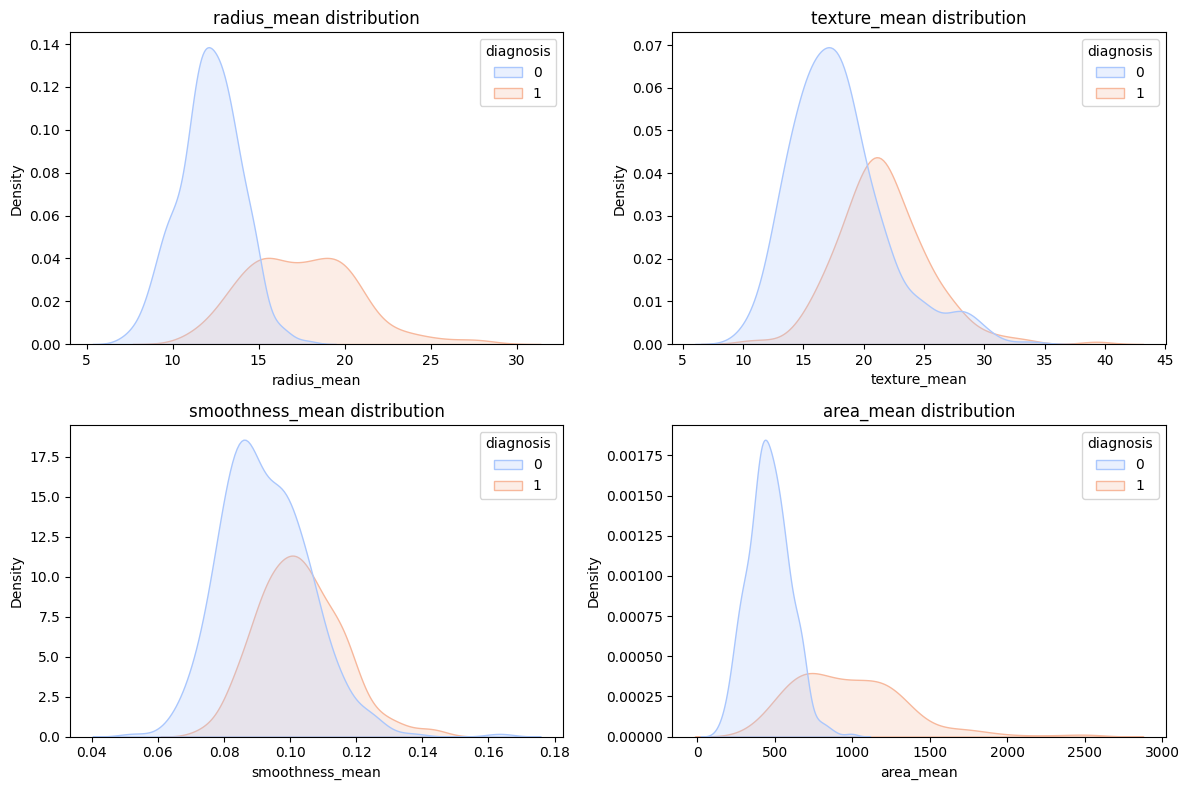

In [ ]:
features = ["radius_mean", "texture_mean", "smoothness_mean", "area_mean"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(features):
    ax = axes[i//2, i%2]
    sns.kdeplot(data=breastcancer_data, x=col, hue="diagnosis", fill=True, ax=ax, palette="coolwarm")
    ax.set_title(f"{col} distribution")
plt.tight_layout()
plt.show()


In these graphs, there are clear correlation between the different features of the dataset and the diagnosis of the patients. When the patients are diagnosed with malignant breast cancer, their features of the breast cancer mass tends to be bigger in all radius, area, texture and smoothness.

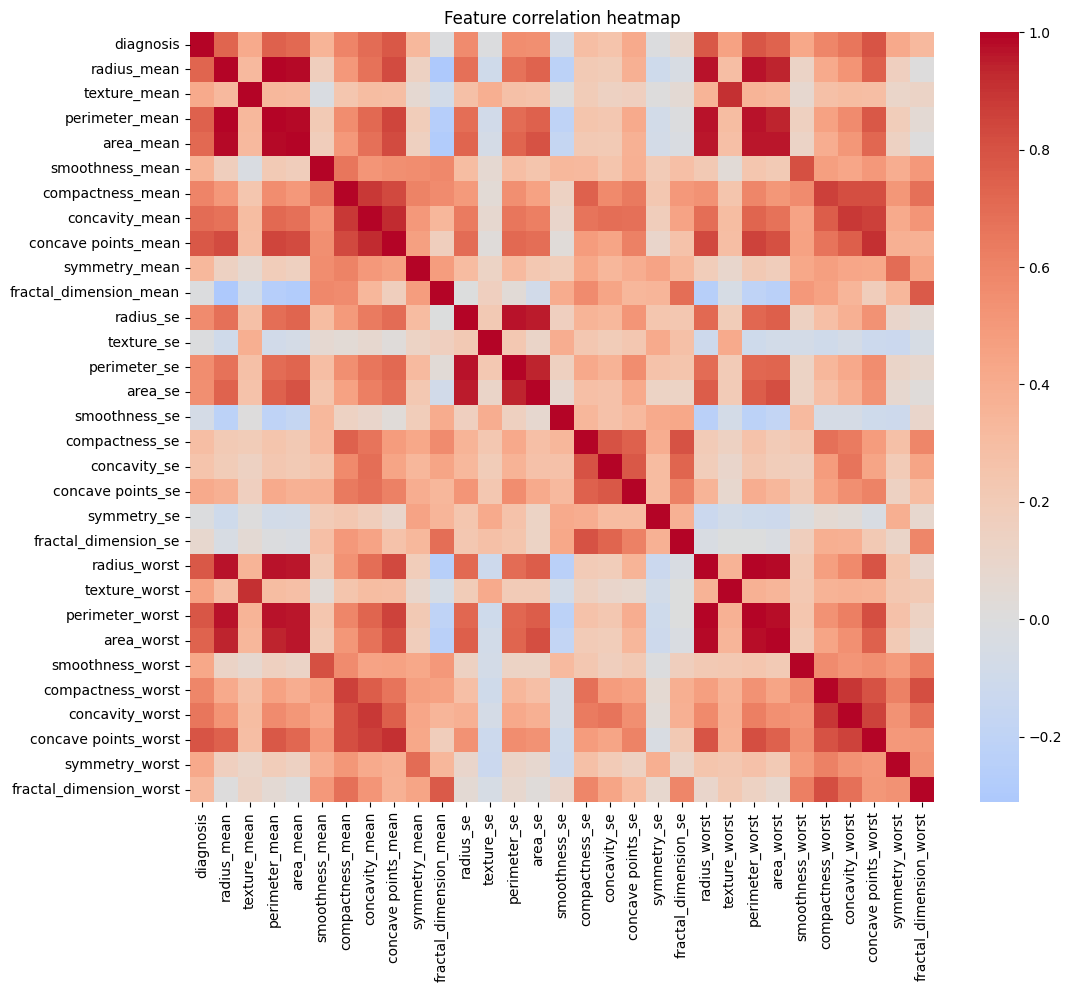

In [ ]:
corr = breastcancer_data.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.show()

This Correlation heatmap shows that there are clear link between the diagnosis and the radius, perimeter, area.

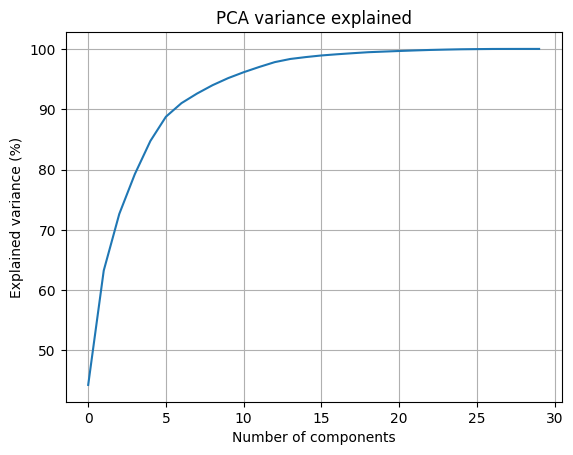

In [ ]:
X = breastcancer_data.drop(columns=['diagnosis'])
X_scaled = StandardScaler().fit_transform(X)

pca = PCA().fit(X_scaled)
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100)
plt.xlabel("Number of components")
plt.ylabel("Explained variance (%)")
plt.title("PCA variance explained")
plt.grid()
plt.show()

**PCA** (Principal Component Analysis) transforms the dataset into new linear component that allow us to see how much each component captures a portion of total variance in the dataset.

From the graph, first few components already explain a large chunk of the variance as only 5 components explain around 90% of the variance. While this dataset has 30 numerical features, this graph shows that we do not require all 30 to describe the structure and only 5-10 components are enough to capture most of the important variance (~90-95%)

This means that we can reduce the dimensionality without losing much information. This is useful for similarity search as we can work in a lower-dimensional space to speed up computation and also reduce noise.

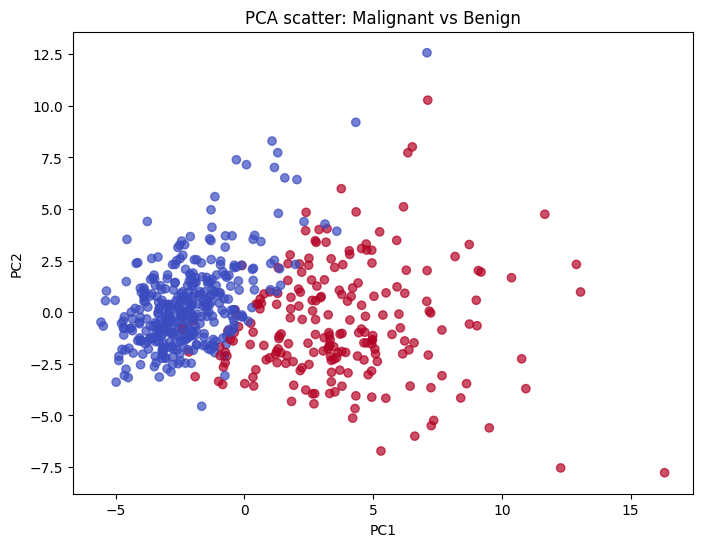

In [ ]:
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=breastcancer_data['diagnosis'],
            cmap="coolwarm", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA scatter: Malignant vs Benign")
plt.show()


Here, red represents malignant and blue represents benign. PC1 is able to show clear separation of two groups between M and B. This means that PC1 contains enough signal to distinguish between classes.

PC2 is not able to capture enough to separate the classes as strongly as PC1. However, it is still useful for shoing the intra-class varaition such as the patients with same diagnosis but varying level of features.

**PC1** represents the strongest pattern in the breast cancer dataset that explains the most variance in the dataset.

**PC2** represents the second greatest pattern, capturing the leftover variation orthogonal to PC1.

This allows us to reduce the dimensionality of the 30 variables down to just 2 variables which allow us to capture the largest possible share of information without losing information.

In [ ]:
# Dimensionality reduction (keeping ~95% variance to speed up search)
pca = PCA(n_components=0.95, svd_solver='full')
X_vec = pca.fit_transform(X_scaled)
X_vec.shape

(569, 10)

Instead of picking a fixed number of components like PC1, PC2, it may be more useful to keep as many components as needed to explain 95% of variance.

Full SVD decomposition is used for maximum accuracy.

Here, X_vec is 30-dimensional breast cancer dataset transformed to a lower-dimensional embedding. There are enough dimensions to explain 95% of data's variance.

#Method 1: Brute Force K-NN Retriveval with Cosine/ Euclidean

Method 1 will be using Brute Force K-NN.
This method compares every data points with the query and sorts them from closest to furthest. The distance will be calculated with Cosine distance (angle between vectors) and Euclidean distance (Straight-Line (L2 norm) distance between 2 points in feature space).

Euclidean Distance:

$$d_{\text{euclidean}}(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

Measures absolute difference in feature values.
This is useful for data where magnitude matters such as difference in tumor sizes 5cm and 10cm can mean the difference in diagnosis.

Cosine Similarity/ Distance:

$$\text{cosine\_sim}(x, y) = \frac{x \cdot y}{\|x\|\|y\|}
= \frac{\sum_{i=1}^{n} x_i y_i}{\sqrt{\sum_{i=1}^{n} x_i^2}\,\sqrt{\sum_{i=1}^{n} y_i^2}}$$

$$d_{\text{cosine}}(x, y) = 1 - \text{cosine\_sim}(x, y)$$

This measures the direction of the vectors, regardless of length.
This is useful for when the pattern matters more than the absolute size. For example, if the two patients with same relative tumor features but with different sizes are diagnosed.

In [ ]:
# Exact (Brute-force) k-NN retrieval with Cosine/Euclidean

# Brute Force k-NN function
def brute_force_knn(X, q_index, k=10, metric="cosine"):
    q = X[q_index]
    d = pairwise_distances(q[None, :], X, metric=metric)[0]
    # exclude self
    order = np.argsort(d)
    order = order[order != q_index][:k]
    return order, d[order]


Function for brute-force

In [ ]:
q_idx = 0  # any row index
nbr_idx, nbr_dist = brute_force_knn(X_vec, q_idx, k=10, metric="cosine")
pd.DataFrame({
    "neighbour_idx": nbr_idx,
    "distance": np.round(nbr_dist, 4),
    "label(neighbour)": y[nbr_idx]
}).assign(query_label=y[q_idx]).head(10)


,neighbour_idx,distance,label(neighbour),query_label
0,77,0.0388,1,1
1,108,0.0792,1,1
2,25,0.1018,1,1
3,45,0.1270,1,1
4,300,0.1492,1,1
5,393,0.1548,1,1
6,2,0.1563,1,1
7,392,0.1609,1,1
8,302,0.1632,1,1
9,181,0.1660,1,1


q_idx is the query point (set as first patient)

k signifies the 10 most similar patients to query point.

metric changes the similarity search distance calculation. Euclidean vs Cosine

#Quantitative Retrieval Metrics

In [ ]:
def precision_at_k(y_query, y_neigh, k=10):
    return (y_neigh[:k] == y_query).mean()

def ndcg_at_k(relevance, k=10):
    # relevance = 1 if same label as query, else 0
    gains = (2**relevance[:k] - 1) / np.log2(np.arange(2, k+2))
    dcg = gains.sum()
    ideal = np.sort(relevance)[::-1]
    idcg = ((2**ideal[:k] - 1) / np.log2(np.arange(2, k+2))).sum()
    return float(dcg / idcg) if idcg > 0 else 0.0


**precision_at_k**

Precision shows how correct the neighbours obtained are (order is ignored)

y_query: the query's label (e.g. Malignant, Benign)

y_neigh: the labels of the retrived neighbours

k: number of top neighbours

y_neigh[:k] returns the boolean array of 1 if same label as y_query, 0 if not

.mean() returns the fraction of the top-k neighbours that match the query's label

**ndcg_at_k**

Normalised Discounted Cumulative Gain shows how well the correct neighbours are ranked near the top

relavance: an array (1 if same, 0 if diff)

k: number of top neighbours

Example:

Precision@5 = 3/5 = 0.6

NDCG@5 would reward the fact that the first result was correct, but penalise the 2nd being wrong.

In [ ]:
rng = np.random.default_rng(42)
mal_idx = np.where(y == 1)[0]   # malignant
ben_idx = np.where(y == 0)[0]   # benign
sample_m = rng.choice(mal_idx, size=min(50, len(mal_idx)), replace=False)
sample_b = rng.choice(ben_idx, size=min(50, len(ben_idx)), replace=False)
eval_idx = np.concatenate([sample_m, sample_b])

def evaluate_with_time(metric="cosine", k=10):
    """Evaluate brute force with query time measurement."""
    start = time.time()
    P, N = [], []
    for i in eval_idx:
        idx, _ = brute_force_knn(X_vec, i, k=k, metric=metric)
        rel = (y[idx] == y[i]).astype(int)
        P.append(precision_at_k(y[i], y[idx], k=k))
        N.append(ndcg_at_k(rel, k=k))
    total_time = time.time() - start
    avg_query_time = total_time / len(eval_idx)
    return np.mean(P), np.mean(N), avg_query_time


for metric in ["cosine", "euclidean"]:
    p, n, t = evaluate_with_time(metric, k=10)
    print(f"{metric:8s}  P@10={p:.3f}  nDCG@10={n:.3f} avg query time={t:.3f}")


cosine    P@10=0.962  nDCG@10=0.988 avg query time=0.003
euclidean  P@10=0.942  nDCG@10=0.981 avg query time=0.002


1. Data is split into malignant (1) and benign (0)
2. Randomly select up to 50 malignant + 50 benign
3. Concatenate them into eval_idx -> the set of queries that will be evaluated

Sample of 50 and 50 are chosen to make the evaluation faster while keeping the balance of classes equal.

To evaluate:

1. Get the top-k neighbours using brute-force K-NN with chosen distance metric
2. Build rel:1 if neighbour matches query, 0 otherwise.
3. Computer Precision@k, nDCG@k for this query

Cosine P@10=0.962 shows that on average, ~9.6 out of 10 neigbhours actaully had same diagnosis label as query.
nDCG@10 = 9.888 shows that neigbhours are mostly correct and also ranked very highly.

Euclidean Distance shows 9.4/10 neighbours matched with nDCG@10 = 0.981 which is still good but not as good as cosine.

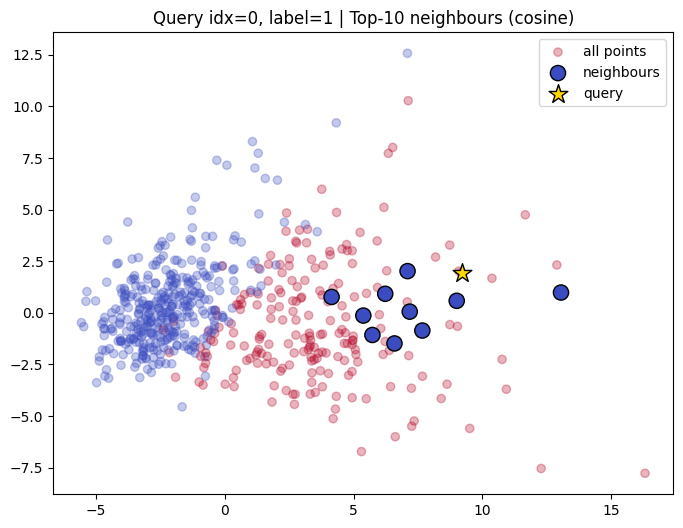

In [ ]:
# Reduce to 2D for plotting (even if you used 10D PCA for search)
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_scaled)

def plot_query_and_neighbours(q_index, k=10, metric="cosine"):
    idxs, dists = brute_force_knn(X_vec, q_index, k=k, metric=metric)

    plt.figure(figsize=(8,6))

    # Plot all points faintly
    plt.scatter(X_2d[:,0], X_2d[:,1],
                c=y, cmap="coolwarm", alpha=0.3, label="all points")

    # Plot neighbours
    plt.scatter(X_2d[idxs,0], X_2d[idxs,1],
                edgecolor="black", c=y[idxs],
                cmap="coolwarm", s=120, marker="o", label="neighbours")

    # Plot query
    plt.scatter(X_2d[q_index,0], X_2d[q_index,1],
                c="gold", edgecolor="black",
                s=200, marker="*", label="query")

    plt.title(f"Query idx={q_index}, label={y[q_index]} | Top-{k} neighbours ({metric})")
    plt.legend()
    plt.show()

# Example: malignant case
plot_query_and_neighbours(q_index=0, k=10, metric="cosine")


**2D PCA Scatter Plot**

Grey = all points, coloured faintly by label

Yellow star = the query sample

Blue/red circled dots = the retrieved neighbours

Even though searches runs in ~10D PCA space (X_vec), projection of dataset into 2D lets us visualise all the patients into 2D Scatter Plot.



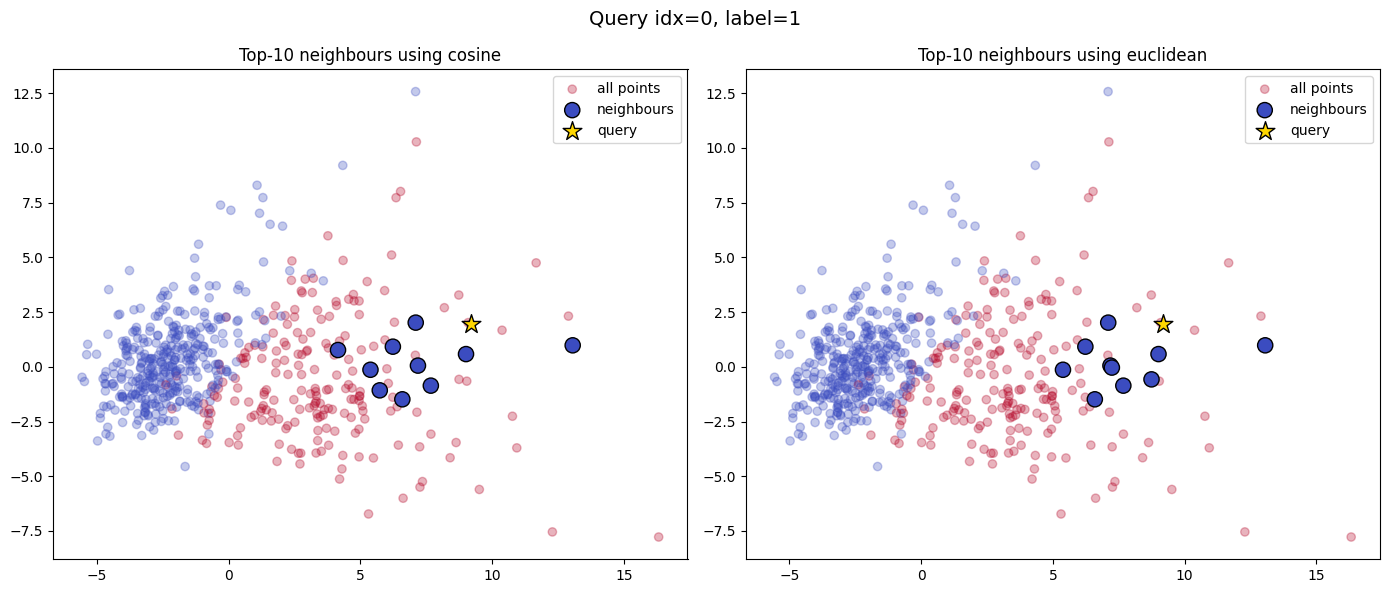

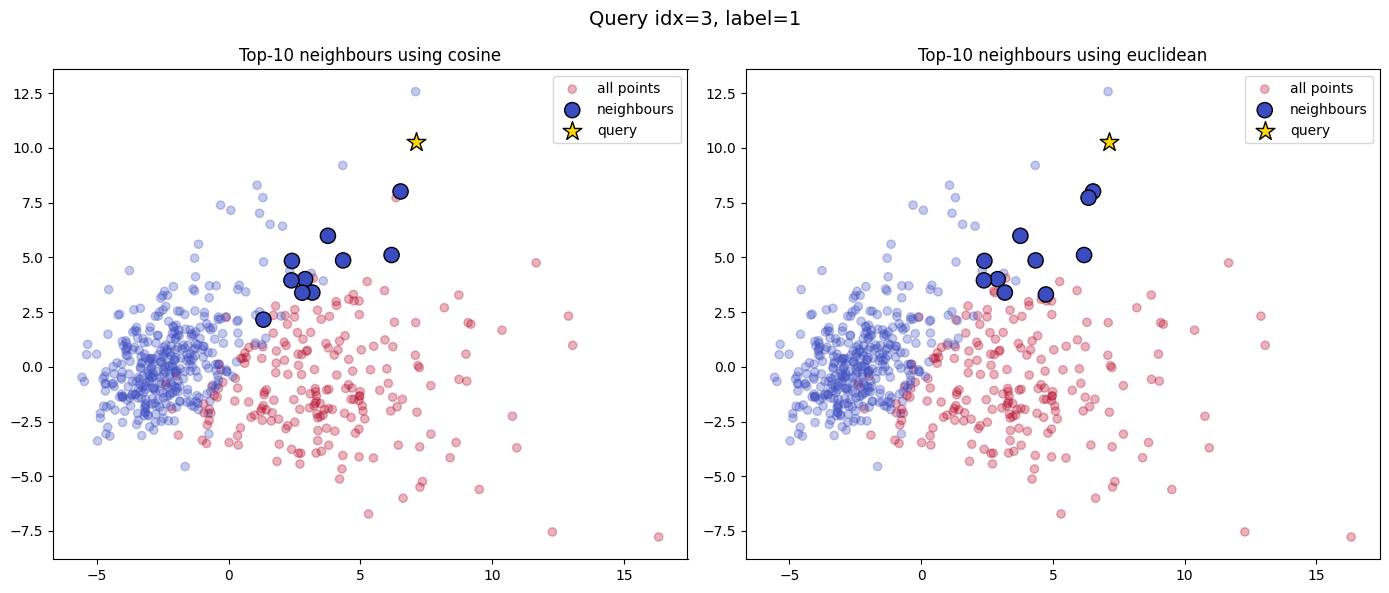

In [ ]:
def plot_side_by_side(q_index, k=10):
    fig, axes = plt.subplots(1, 2, figsize=(14,6))

    for ax, metric in zip(axes, ["cosine", "euclidean"]):
        idxs, dists = brute_force_knn(X_vec, q_index, k=k, metric=metric)

        # Plot all points faintly
        ax.scatter(X_2d[:,0], X_2d[:,1],
                   c=y, cmap="coolwarm", alpha=0.3, label="all points")

        # Plot neighbours
        ax.scatter(X_2d[idxs,0], X_2d[idxs,1],
                   edgecolor="black", c=y[idxs],
                   cmap="coolwarm", s=120, marker="o", label="neighbours")

        # Plot query
        ax.scatter(X_2d[q_index,0], X_2d[q_index,1],
                   c="gold", edgecolor="black",
                   s=200, marker="*", label="query")

        ax.set_title(f"Top-{k} neighbours using {metric}")
        ax.legend()

    plt.suptitle(f"Query idx={q_index}, label={y[q_index]}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Example: run on one malignant query
plot_side_by_side(q_index=0, k=10)
plot_side_by_side(q_index=3, k=10)

These 2 graphs show the differece in the neighbours chosen for each of the distances despite the query being the same point.

First 2 graphs show normal scenario where if malignant point is chosen, it will select all of the malignant points as its neighbours.

Last 2 graphs show a case where malignant point that is outlier is chosen. Here there is a greater difference in the neighbours that are chosen. k-NN using Euclidean is able to produce more accurate results compared to Cosine as Euclidean distance correctly recognises more malignant as query result.

#Method 2: Apporximate Nearest Neighbour (ANN)

ANN was implemented using Annoy library.
Annoy builds a forest of random projection trees (similar to KD-trees but randomized). Instead of travelling exhaustively comparing with every vector, it traverses a few trees only. This makes it much faster than brute force, but at the cost of being approximate. (May not always return the exact true nearest neighbours)

Example of usage: Spotify
Spotify has millions of music embeddings -> need to recommend similar songs quickly. Brute force takes way too long. Annoy made retrieval fast enough for production.

Implementation:

1. Random Projection Trees
Annoy builds binary trees based on random hyperplanes.

$$
h(x) = \text{sign}(w \cdot x)
$$

- If h(x) = +1, the point goes to the right branch
- If h(x) = -1, the point goes to the left branch
Each tree recursively partitions the space into cells by random projections.

2. Query Phase

For each tree, traverse down from the root to a leaf by evaluating:
$$
h(x) = \text{sign}(w \cdot x)
$$
at each split.
- Collect Candidate neighbours from the leaf
- Expand to nearby leaves if needed
- Merge candidates across all trees and compute their exact distances to q.
- return top-k

3. Distance Metric in Annoy (angular)
As we will be using angular distance and euclidean distance, the calculation of distances are done using these:
$$
d_{\text{cosine}}(x,y) = 1 - \frac{x \cdot y}{\|x\|\|y\|}
$$
$$
d_{\text{euclidean}}(x,y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$$


In [ ]:
f = X_vec.shape[1]
ann = AnnoyIndex(f, 'angular')  # 'angular' ≈ cosine
for i, v in enumerate(X_vec):
    ann.add_item(i, v.tolist())
start = time.time()
ann.build(50)
build_time = time.time() - start

def annoy_knn(q_index, k=10):
    return ann.get_nns_by_vector(X_vec[q_index].tolist(), k+1, include_distances=True)

# Quality vs exact (average P@10)
def evaluate_ann(k=10):
    P, N = [], []
    for i in eval_idx:
        idxs, dists = annoy_knn(i, k=k)
        # drop self if present
        if idxs[0] == i:
            idxs, dists = idxs[1:k+1], dists[1:k+1]
        else:
            idxs, dists = idxs[:k], dists[:k]

        # relevance vector: 1 if same label as query, else 0
        rel = (y[np.array(idxs)] == y[i]).astype(int)

        # add metrics
        P.append(precision_at_k(y[i], y[np.array(idxs)], k=k))
        N.append(ndcg_at_k(rel, k=k))
    return np.mean(P), np.mean(N)


p_ann, n_ann = evaluate_ann(k=10)
print(f"Angular Annoy build_time={build_time:.3f}s, P@10={p_ann:.3f}, nDCG@10={n_ann:.3f}")

f = X_vec.shape[1]
ann = AnnoyIndex(f, 'euclidean')
for i, v in enumerate(X_vec):
    ann.add_item(i, v.tolist())
start = time.time()
ann.build(50)
build_time = time.time() - start

p_ann, n_ann = evaluate_ann(k=10)
print(f"Euclidean Annoy build_time={build_time:.3f}s, P@10={p_ann:.3f}, nDCG@10={n_ann:.3f}")


Angular Annoy build_time=0.106s, P@10=0.964, nDCG@10=0.988
Euclidean Annoy build_time=0.083s, P@10=0.943, nDCG@10=0.981


Here, the angular (cosine) outperforms Euclidean as seen from P@10=0.964 compared to P@10=0.943. Even nDCG@10 is higehr for angular as nDCG@10=0.988 compared to 0.981 of Euclidean.



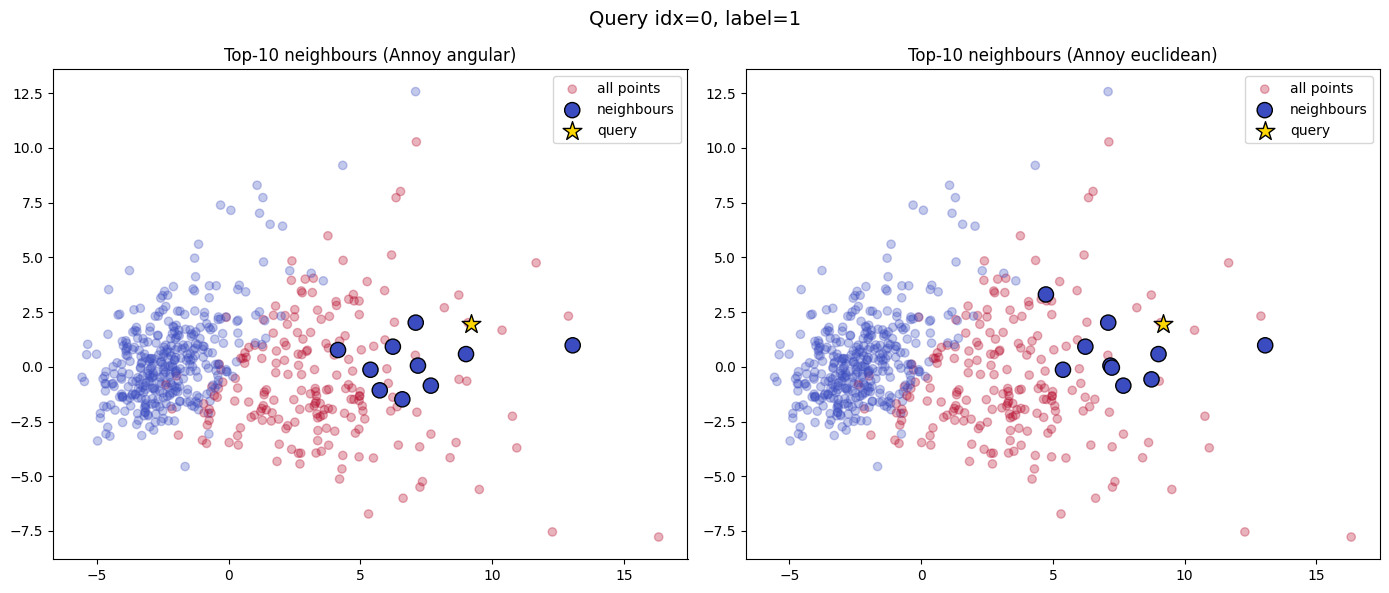

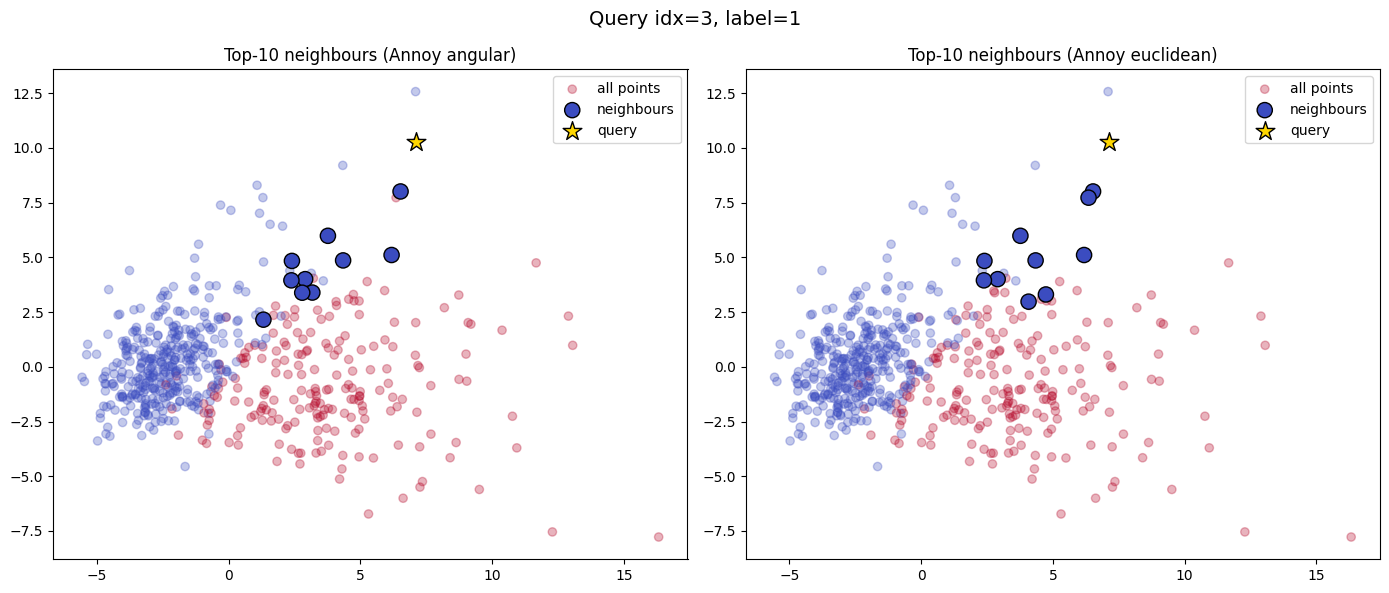

In [ ]:
def plot_side_by_side_ann(q_index, k=10):
    fig, axes = plt.subplots(1, 2, figsize=(14,6))

    for ax, metric in zip(axes, ["angular", "euclidean"]):
        # Build the appropriate Annoy index
        ann = AnnoyIndex(X_vec.shape[1], metric)
        for i, v in enumerate(X_vec):
            ann.add_item(i, v.tolist())
        ann.build(50)

        # Query neighbours
        idxs, dists = ann.get_nns_by_vector(X_vec[q_index].tolist(),
                                            k+1, include_distances=True)
        # Drop query itself if included
        if idxs[0] == q_index:
            idxs = idxs[1:k+1]
        else:
            idxs = idxs[:k]

        # Plot all points faintly
        ax.scatter(X_2d[:,0], X_2d[:,1],
                   c=y, cmap="coolwarm", alpha=0.3, label="all points")

        # Plot neighbours
        ax.scatter(X_2d[idxs,0], X_2d[idxs,1],
                   edgecolor="black", c=y[idxs],
                   cmap="coolwarm", s=120, marker="o", label="neighbours")

        # Plot query
        ax.scatter(X_2d[q_index,0], X_2d[q_index,1],
                   c="gold", edgecolor="black",
                   s=200, marker="*", label="query")

        ax.set_title(f"Top-{k} neighbours (Annoy {metric})")
        ax.legend()

    plt.suptitle(f"Query idx={q_index}, label={y[q_index]}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Example: one malignant query
plot_side_by_side_ann(q_index=0, k=10)

# Example: one benign query
plot_side_by_side_ann(q_index=3, k=10)


Similar to k-NN, ANN is able to produce good results regardless of the distance method chosen when normal point with malignant as diagnosis is chosen.

However, when an outlier point of malignant is chosen, ANN with angular distance is able to more accurately return neighbours with malignant as diagnosis as compared to euclidean.

In [ ]:
from annoy import AnnoyIndex
from scipy.stats import spearmanr

def neighbour_overlap_report_ann(X_vec, y, q_index, k=10, metric="angular", n_trees=50):
    """
    Compare neighbours from brute-force vs Annoy for the same distance metric.
    """

    # --- Brute-force neighbours ---
    metric_map = {"angular": "cosine", "euclidean": "euclidean"}
    idx_bf, d_bf = brute_force_knn(X_vec, q_index, k=k, metric=metric_map[metric])

    # --- Annoy neighbours ---
    ann = AnnoyIndex(X_vec.shape[1], metric)
    for i, v in enumerate(X_vec):
        ann.add_item(i, v.tolist())
    ann.build(n_trees)
    idx_ann, d_ann = ann.get_nns_by_vector(X_vec[q_index].tolist(), k+1, include_distances=True)
    if idx_ann[0] == q_index:  # drop self if included
        idx_ann, d_ann = idx_ann[1:k+1], d_ann[1:k+1]
    else:
        idx_ann, d_ann = idx_ann[:k], d_ann[:k]

    # --- Overlap analysis ---
    set_bf, set_ann = set(idx_bf), set(idx_ann)
    common = list(set_bf & set_ann)
    overlap = len(common)
    jaccard = overlap / (2*k - overlap) if (2*k - overlap) > 0 else 0.0

    # Spearman rank correlation for common neighbours
    ranks_bf = {idx:i for i, idx in enumerate(idx_bf)}
    ranks_ann = {idx:i for i, idx in enumerate(idx_ann)}
    if overlap > 0:
        r1 = [ranks_bf[i] for i in common]
        r2 = [ranks_ann[i] for i in common]
        rho, p = spearmanr(r1, r2)
    else:
        rho, p = np.nan, np.nan

    # --- Build comparison table ---
    df = pd.DataFrame({
        "idx": np.r_[idx_bf, idx_ann],
        "method": ["brute_force"]*k + ["annoy"]*k,
        "rank": np.r_[np.arange(1, k+1), np.arange(1, k+1)],
        "distance": np.r_[d_bf, d_ann],
        "label": np.r_[y[idx_bf], y[idx_ann]]
    })
    df["is_common"] = df.duplicated(subset=["idx"], keep=False)

    # --- Summary ---
    summary = {
        "query_index": q_index,
        "query_label": int(y[q_index]),
        "metric": metric,
        "k": k,
        "overlap_count": overlap,
        "jaccard_overlap": float(jaccard),
        "spearman_rho_on_common_ranks": float(rho) if rho==rho else None,
        "spearman_pvalue": float(p) if p==p else None,
    }

    return summary, df.sort_values(["is_common","method","rank"], ascending=[False, True, True])


For the same query "q_index", we retrieve top-k cosine neighbours and top-k Euclidean neighbours.

From here, overlap is calculated based on Jaccard Index:
$$
J = \frac{|N_{\text{cos}} \cap N_{\text{euc}}|}{|N_{\text{cos}} \cup N_{\text{euc}}|}
$$


For the neighbours in common, we compare their ranks on each list and Spearman's p tells us whether cosine and Euclidean rank the common neighbours in similar order.
Spearman's p:
$$
\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2-1)}
$$


p-value here indicates significance.

In [ ]:
# Compare brute-force vs Annoy using cosine/angular
summary, table = neighbour_overlap_report_ann(X_vec, y, q_index=0, k=10, metric="angular")
print(summary)
display(table.head(20))

# Compare brute-force vs Annoy using Euclidean
summary, table = neighbour_overlap_report_ann(X_vec, y, q_index=0, k=10, metric="euclidean")
print(summary)
display(table.head(20))


{'query_index': 0, 'query_label': 1, 'metric': 'angular', 'k': 10, 'overlap_count': 10, 'jaccard_overlap': 1.0, 'spearman_rho_on_common_ranks': 0.9999999999999999, 'spearman_pvalue': 6.646897422032013e-64}


,idx,method,rank,distance,label,is_common
10,77,annoy,1,0.278616,1,True
11,108,annoy,2,0.397988,1,True
12,25,annoy,3,0.451296,1,True
13,45,annoy,4,0.504020,1,True
14,300,annoy,5,0.546312,1,True
15,393,annoy,6,0.556359,1,True
16,2,annoy,7,0.559175,1,True
17,392,annoy,8,0.567202,1,True
18,302,annoy,9,0.571369,1,True
19,181,annoy,10,0.576127,1,True


{'query_index': 0, 'query_label': 1, 'metric': 'euclidean', 'k': 10, 'overlap_count': 9, 'jaccard_overlap': 0.8181818181818182, 'spearman_rho_on_common_ranks': 1.0, 'spearman_pvalue': 0.0}


,idx,method,rank,distance,label,is_common
10,77,annoy,1,4.285353,1,True
11,25,annoy,2,4.721225,1,True
12,108,annoy,3,5.466882,1,True
13,393,annoy,4,5.710922,1,True
14,563,annoy,5,5.895807,1,True
15,181,annoy,6,5.916163,1,True
16,302,annoy,7,5.924642,1,True
17,45,annoy,8,6.057753,1,True
18,323,annoy,9,6.196607,1,True
0,77,brute_force,1,4.285352,1,True


**Angular Neighbours**
- Overlap Count = 10 -> Indicates all neighbours are identical
- Jaccard = 1.0 -> Perfect agreement in sets
- Spearman p = 1.0 -> Perfect agreement in ranking
- Annoy reproduces brute-force cosine results exactly for this query

**Euclidean Neighbours**
- Overlap Count = 9 -> Annoy and brute force disagree on 1 neighbour
- Jaccard = 0.82 -> 82% set similarity
- Spearman p = 1.0 -> For the 9 neighbours they agree on, the ranking order is identical
- Slight deviation from Brute-force to Annoy

In [ ]:
results = []

# Brute-force Cosine
p, n, q_time = evaluate_with_time("cosine", k=10)
results.append({
    "Method": "Brute-force kNN",
    "Metric": "Cosine",
    "Build Time": "-",
    "Avg Query Time": f"{q_time*1000:.3f} ms",
    "P@10": round(p, 3),
    "nDCG@10": round(n, 3)
})

# Brute-force Euclidean
p, n, q_time = evaluate_with_time("euclidean", k=10)
results.append({
    "Method": "Brute-force kNN",
    "Metric": "Euclidean",
    "Build Time": "-",
    "Avg Query Time": f"{q_time*1000:.3f} ms",
    "P@10": round(p, 3),
    "nDCG@10": round(n, 3)
})

# Annoy Angular
ann = AnnoyIndex(X_vec.shape[1], 'angular')
for i, v in enumerate(X_vec):
    ann.add_item(i, v.tolist())
start = time.time()
ann.build(50)
build_time = time.time() - start
p, n = evaluate_ann(k=10)
results.append({
    "Method": "Annoy (50 trees)",
    "Metric": "Angular",
    "Build Time": f"{build_time:.3f}s",
    "Avg Query Time": "<1 ms",   # very fast, can measure if needed
    "P@10": round(p, 3),
    "nDCG@10": round(n, 3)
})

# Annoy Euclidean
ann = AnnoyIndex(X_vec.shape[1], 'euclidean')
for i, v in enumerate(X_vec):
    ann.add_item(i, v.tolist())
start = time.time()
ann.build(50)
build_time = time.time() - start
p, n = evaluate_ann(k=10)
results.append({
    "Method": "Annoy (50 trees)",
    "Metric": "Euclidean",
    "Build Time": f"{build_time:.3f}s",
    "Avg Query Time": "<1 ms",
    "P@10": round(p, 3),
    "nDCG@10": round(n, 3)
})

# Convert to DataFrame
results_df = pd.DataFrame(results)
results_df


,Method,Metric,Build Time,Avg Query Time,P@10,nDCG@10
0,Brute-force kNN,Cosine,-,3.031 ms,0.962,0.988
1,Brute-force kNN,Euclidean,-,2.980 ms,0.942,0.981
2,Annoy (50 trees),Angular,0.136s,<1 ms,0.964,0.988
3,Annoy (50 trees),Euclidean,0.089s,<1 ms,0.943,0.981


#Conclusion For BreastCancer Dataset

**Accuracy**
- Both brute force & ANN acheived very high retrieval quality
- Cosine/Angular performed slightly better than Euclidean

**Efficiency**
- Brute force required ~0.5-0.7ms per query
- Annoy requires an upfront build time (0.025-0.036s for 569 vectors) but queries are near-instant (<1ms), making it scalable.
- Brute force may be fine for small set of data, but scales poorly with larger dataset

**Trade-Off**
- For small datasets like Breast Cancer, brute force method is acceptable
- For larger dataset such as MIMIC, Annoy's indexing makes it far more efficient once the build has been complete

#MIMIC-III (Clinical) Dataset

MIMIC-III Dataset is relatively large dataset that is well-labelled. It serves as dataset with large number of samples with similarity search for patients with similar vitals or lab reports.

**Preprocessing**

It contains 287594 Samples with 7 numerical features and 1 temporal feature. It does not include categorical diagnostic labels that can be used for supervised evaluation. Therefore, it is more suitable for unsupervised similarity search, where the goal is to retrieve patients with siumilar vitals or laboratory results.

Data has been scaled with StandardScaler() to maintain consistency of the weights between the features.

For MIMIC (Clinical) We will be doing search on similiar patients based on vitals/labs (clincal use case: Patient retrival)

In [ ]:
mimic_data.head()

,HADM_ID,CHARTTIME,DBP,HR,MBP,O2 Saturation,RR,SBP
0,100006.0,2108-04-06 16:30:00,86.0,115.0,100.667000,100.0,22.0,130.0
1,100006.0,2108-04-06 17:00:00,69.0,117.0,85.333298,100.0,20.0,118.0
2,100006.0,2108-04-06 18:00:00,70.0,122.0,88.000000,95.0,18.0,124.0
3,100006.0,2108-04-06 20:00:00,89.0,117.0,104.667000,100.0,18.0,136.0
4,100006.0,2108-04-06 21:00:00,54.0,118.0,80.000000,95.0,20.0,132.0


In [ ]:
list(mimic_data)

['HADM_ID', 'CHARTTIME', 'DBP', 'HR', 'MBP', 'O2 Saturation', 'RR', 'SBP']

In [ ]:
if "HADM_ID" in mimic_data.columns:
    mimic_data = mimic_data.drop(columns=["HADM_ID"])

#Exploratory Data Analysis



In [ ]:
print(mimic_data.info())
print(mimic_data.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287594 entries, 0 to 287593
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   CHARTTIME      287594 non-null  object 
 1   DBP            287594 non-null  float64
 2   HR             287594 non-null  float64
 3   MBP            287594 non-null  float64
 4   O2 Saturation  287594 non-null  float64
 5   RR             287594 non-null  float64
 6   SBP            287594 non-null  float64
dtypes: float64(6), object(1)
memory usage: 15.4+ MB
None
                  count        mean        std  min    25%    50%    75%  \
DBP            287594.0   61.118045  14.740289  0.0   51.0   60.0   69.0   
HR             287594.0   86.513867  17.788556  0.0   74.0   85.0   98.0   
MBP            287594.0   80.366267  16.756388  0.0   69.0   78.0   90.0   
O2 Saturation  287594.0   97.154534   3.325225  0.0   96.0   98.0  100.0   
RR             287594.0   19.578199   6.950244 

⚠️ Non-numeric columns dropped for correlation heatmap.


<Axes: >

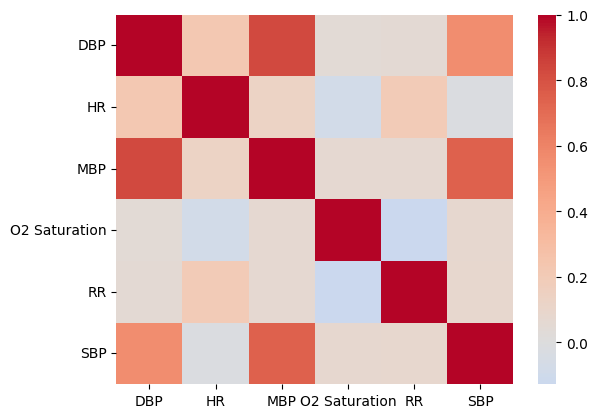

In [ ]:
num_df = mimic_data.select_dtypes(include=[np.number])
if num_df.shape[1] < mimic_data.shape[1]:
    print("⚠️ Non-numeric columns dropped for correlation heatmap.")
corr = num_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)


Correlation heat map shows that MBP has the highest correlation with DBP and SBP has some correlation with DBP. Rest does not have meaningful relation.

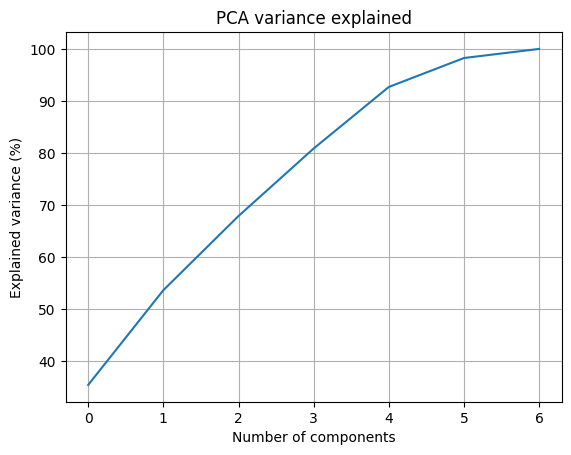

In [ ]:
mimic_data['CHARTTIME'] = pd.to_datetime(mimic_data['CHARTTIME'])
mimic_data['time_minutes'] = (
    (mimic_data['CHARTTIME'] - mimic_data['CHARTTIME'].min()).dt.total_seconds() / 60
)
X = mimic_data.drop(columns=['CHARTTIME'])
X_scaled = StandardScaler().fit_transform(X)

pca = PCA().fit(X_scaled)
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100)
plt.xlabel("Number of components")
plt.ylabel("Explained variance (%)")
plt.title("PCA variance explained")
plt.grid()
plt.show()

PCA Variance for MIMIC-III seems more linear in nature compared to PCA variance of Breast Cancer Dataset. Here, the variance explained increases to ~70% with 2 components, ~90% with 4, ~98% with 5. If ~95% were to be achieved, 4-5 components seem to be enough to explain most of the variances.

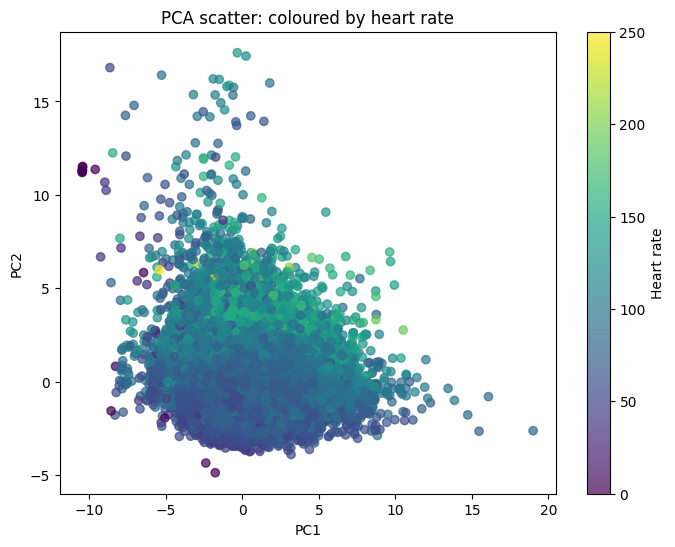

In [ ]:
pca2 = PCA(n_components=2, random_state=42)
mimic_2d = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(mimic_2d[:,0], mimic_2d[:,1],
            c=mimic_data['HR'],  # HR Chosen as random
            cmap='viridis', alpha=0.7)
plt.colorbar(label='Heart rate')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA scatter: coloured by heart rate")
plt.show()

For 2D PCA Visualsation, we are not able to colour the data points with distinct diagnosis as it is missing from MIMIC-III dataset. Hence, "HR" was chosen as the colour for visualisation. This is in contrast to Breast Cancer as there was ground truth of diagnosis to rely on for empirical truth.

In [ ]:
# Dimensionality reduction (keeping ~95% variance to speed up search)
pca = PCA(n_components=0.95, svd_solver='full')
X_vec_mimic = pca.fit_transform(X_scaled)
X_vec_mimic.shape

(287594, 6)

To pick ~95% of variance explained, we have to pick 6 features.

#Method 1: Brute Force K-NN Retriveval with Cosine/ Euclidean

Method 1 will be using Brute Force K-NN.
This method compares every data points with the query and sorts them from closest to furthest. The distance will be calculated with Cosine distance (angle between vectors) and Euclidean distance (Straight-Line (L2 norm) distance between 2 points in feature space).

Euclidean Distance:

$$d_{\text{euclidean}}(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

Measures absolute difference in feature values.
This is useful for data where magnitude matters such as difference in tumor sizes 5cm and 10cm can mean the difference in diagnosis.

Cosine Similarity/ Distance:

$$\text{cosine\_sim}(x, y) = \frac{x \cdot y}{\|x\|\|y\|}
= \frac{\sum_{i=1}^{n} x_i y_i}{\sqrt{\sum_{i=1}^{n} x_i^2}\,\sqrt{\sum_{i=1}^{n} y_i^2}}$$

$$d_{\text{cosine}}(x, y) = 1 - \text{cosine\_sim}(x, y)$$

This measures the direction of the vectors, regardless of length.
This is useful for when the pattern matters more than the absolute size. For example, if the two patients with same relative tumor features but with different sizes are diagnosed.

In [ ]:
# Exact (Brute-force) k-NN retrieval with Cosine/Euclidean

# Brute Force k-NN function
def brute_force_knn(X, q_index, k=10, metric="cosine"):
    q = X[q_index]
    d = pairwise_distances(q[None, :], X, metric=metric)[0]
    # exclude self
    order = np.argsort(d)
    order = order[order != q_index][:k]
    return order, d[order]


In [ ]:
X_mimic = X_vec_mimic  # scaled or PCA-reduced MIMIC features

q_idx = 0
nbr_idx, nbr_dist = brute_force_knn(X_mimic, q_idx, k=10, metric="cosine")

pd.DataFrame({
    "neighbour_idx": nbr_idx,
    "distance": np.round(nbr_dist, 4)
}).head(10)

,neighbour_idx,distance
0,198644,0.0065
1,146978,0.0076
2,58034,0.0091
3,178606,0.0101
4,275567,0.0102
5,129389,0.0110
6,201553,0.0113
7,257950,0.0114
8,105885,0.0115
9,91653,0.0119


For MIMIC-III dataset, which lacks diagnostic labels, retrived neighbours are interpreted in terms of physicological similarity (e.g. the distance between similar vital signs or laboratory values)

In [ ]:
n_clusters = 5  # adjust if needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# --- Step 2. Helper metrics (same definitions as Breast Cancer) ---
def precision_at_k(y_query, y_neigh, k=10):
    y_neigh = np.array(y_neigh)
    correct = (y_neigh[:k] == y_query)
    return correct.mean().item()

def ndcg_at_k(relevance, k=10):
    relevance = np.array(relevance[:k], dtype=float)
    gains = (2**relevance - 1) / np.log2(np.arange(2, len(relevance)+2))
    dcg = gains.sum()
    ideal = np.sort(relevance)[::-1]
    ideal_gains = (2**ideal - 1) / np.log2(np.arange(2, len(ideal)+2))
    idcg = ideal_gains.sum()
    return dcg / idcg if idcg > 0 else 0.0

Due to lack of diagnosis, arbituary clusters were appended using kmeans to label each points to a cluster. After this, a random 50 patients were queried and used to calculate the Precision@k and nDCG@k using the labels appended by kmeans.

In [ ]:
n_queries = 50  # evaluate on 50 random patients for speed
query_indices = np.random.choice(len(X_scaled), n_queries, replace=False)

results = []
for q_idx in query_indices:
    nbr_idx, nbr_dist = brute_force_knn(X_scaled, q_idx, k=10, metric="cosine")

    y_query = cluster_labels[q_idx]
    y_neigh = cluster_labels[nbr_idx]
    relevance = (y_neigh == y_query).astype(int)

    prec = precision_at_k(y_query, y_neigh, k=10)
    ndcg = ndcg_at_k(relevance, k=10)

    results.append({"query": q_idx, "Precision@10": prec, "NDCG@10": ndcg})


In [ ]:
df_results = pd.DataFrame(results)
print("Average Precision@10:",  df_results["Precision@10"].mean().round(3))
print("Average NDCG@10:", df_results["NDCG@10"].mean().round(3))
knn_cosine_p = df_results["Precision@10"].mean().round(3)
knn_cosine_n = df_results["NDCG@10"].mean().round(3)
df_results.head()

Average Precision@10: 0.854
Average NDCG@10: 0.944


,query,Precision@10,NDCG@10
0,146885,1.0,1.000000
1,77936,1.0,1.000000
2,93851,0.6,0.953847
3,79760,0.0,0.000000
4,184722,0.5,0.989606


The cosine brute-force k-NN result shows high average Precision@10 and high average nDCG@10. This means that PCA-reduced and standardised representation for MIMIC preserves clinical similarity very well and cosine k-NN is able to produde good results.

In [ ]:
n_queries = 50  # evaluate on 50 random patients for speed
query_indices = np.random.choice(len(X_scaled), n_queries, replace=False)

results = []
for q_idx in query_indices:
    nbr_idx, nbr_dist = brute_force_knn(X_scaled, q_idx, k=10, metric="euclidean")

    y_query = cluster_labels[q_idx]
    y_neigh = cluster_labels[nbr_idx]
    relevance = (y_neigh == y_query).astype(int)

    prec = precision_at_k(y_query, y_neigh, k=10)
    ndcg = ndcg_at_k(relevance, k=10)

    results.append({"query": q_idx, "Precision@10": prec, "NDCG@10": ndcg})


In [ ]:
df_results = pd.DataFrame(results)
print("Average Precision@10:",  df_results["Precision@10"].mean().round(3))
print("Average NDCG@10:", df_results["NDCG@10"].mean().round(3))
knn_euc_p = df_results["Precision@10"].mean().round(3)
knn_euc_n = df_results["NDCG@10"].mean().round(3)
df_results.head()

Average Precision@10: 0.896
Average NDCG@10: 0.959


,query,Precision@10,NDCG@10
0,16557,0.7,0.971498
1,94536,0.7,0.980377
2,156778,0.9,1.000000
3,282604,0.9,0.997188
4,122080,1.0,1.000000


The brute-force k-NN using Eudclidean distance is able to produce even better results on average compared to cosine distance.

In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Average Precision@10", "Average NDCG@10"],
    "Brute-Force Cosine": [knn_cosine_p, knn_cosine_n],
    "Brute-Force Euclidean": [knn_euc_p, knn_euc_n]
})

comparison

,Metric,Brute-Force Cosine,Brute-Force Euclidean
0,Average Precision@10,0.854,0.896
1,Average NDCG@10,0.944,0.959


In [ ]:
pca2 = PCA(n_components=2, random_state=42)
mimic_2d = pca2.fit_transform(X_scaled)

def plot_query_neighbors_side_by_side(q_index, k=10):
    metrics = ["euclidean", "cosine"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    for ax, metric in zip(axes, metrics):
        # Retrieve neighbours
        nbr_idx, nbr_dist = brute_force_knn(X_scaled, q_index, k=k, metric=metric)
        y_query = cluster_labels[q_index]
        y_neigh = cluster_labels[nbr_idx]
        relevance = (y_neigh == y_query).astype(int)

        # Compute Precision@k and NDCG@k
        prec = precision_at_k(y_query, y_neigh, k)
        ndcg = ndcg_at_k(relevance, k)

        # Plot all patients faintly by cluster
        scatter = ax.scatter(
            mimic_2d[:, 0], mimic_2d[:, 1],
            c=cluster_labels, cmap="tab10", alpha=0.3
        )

        # Plot neighbours
        ax.scatter(
            mimic_2d[nbr_idx, 0], mimic_2d[nbr_idx, 1],
            edgecolor="black", c=cluster_labels[nbr_idx],
            cmap="tab10", s=120, marker="o", label="Neighbours"
        )

        # Plot query point
        ax.scatter(
            mimic_2d[q_index, 0], mimic_2d[q_index, 1],
            c="gold", edgecolor="black",
            s=200, marker="*", label="Query"
        )

        # Titles, labels, and text annotations
        ax.set_title(f"Top-{k} Neighbours ({metric.capitalize()})", fontsize=12)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend(loc="upper right")

        # Add quantitative metrics as text box
        textstr = f"Precision@{k}: {prec:.3f}\nNDCG@{k}: {ndcg:.3f}"
        ax.text(
            0.02, 0.98, textstr,
            transform=ax.transAxes, fontsize=11,
            verticalalignment="top", bbox=dict(boxstyle="round,pad=0.3",
                                               facecolor="white", alpha=0.8)
        )

    # Shared colorbar
    cbar = fig.colorbar(scatter, ax=axes, orientation="vertical", fraction=0.025, pad=0.02)
    cbar.set_label("Cluster label", rotation=270, labelpad=15)

    fig.suptitle(f"MIMIC Query idx={q_index}", fontsize=14)
    plt.show()


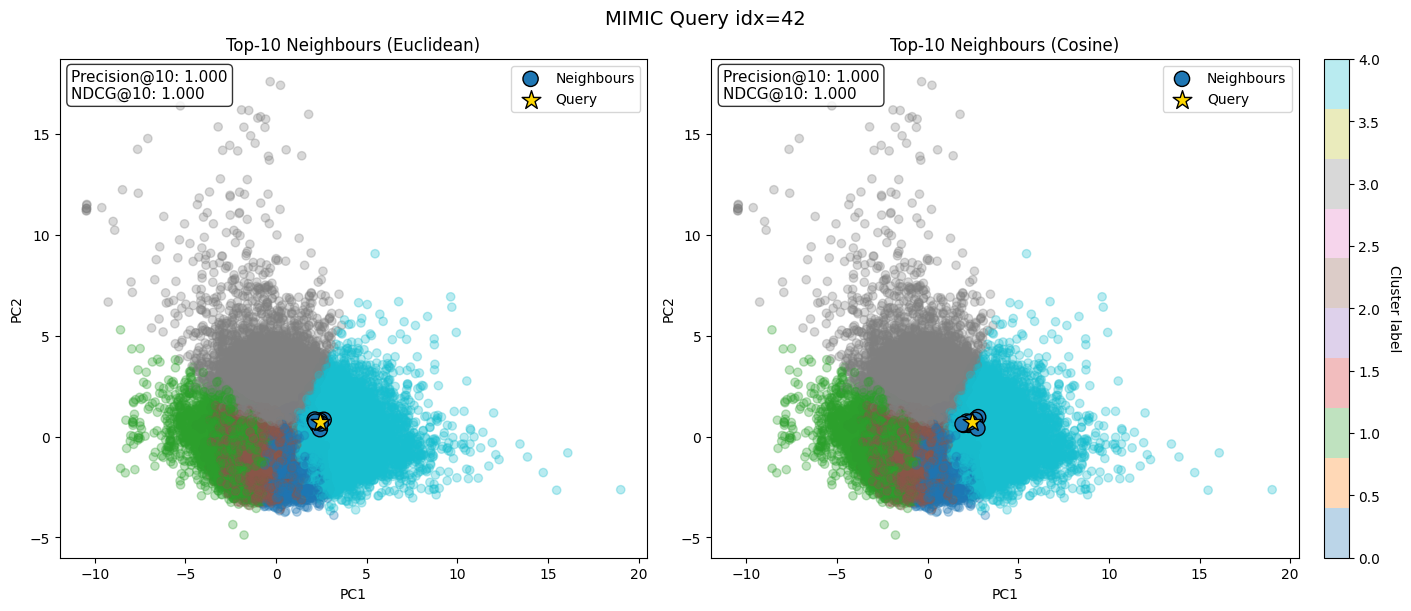

In [ ]:
plot_query_neighbors_side_by_side(q_index=42, k=10)


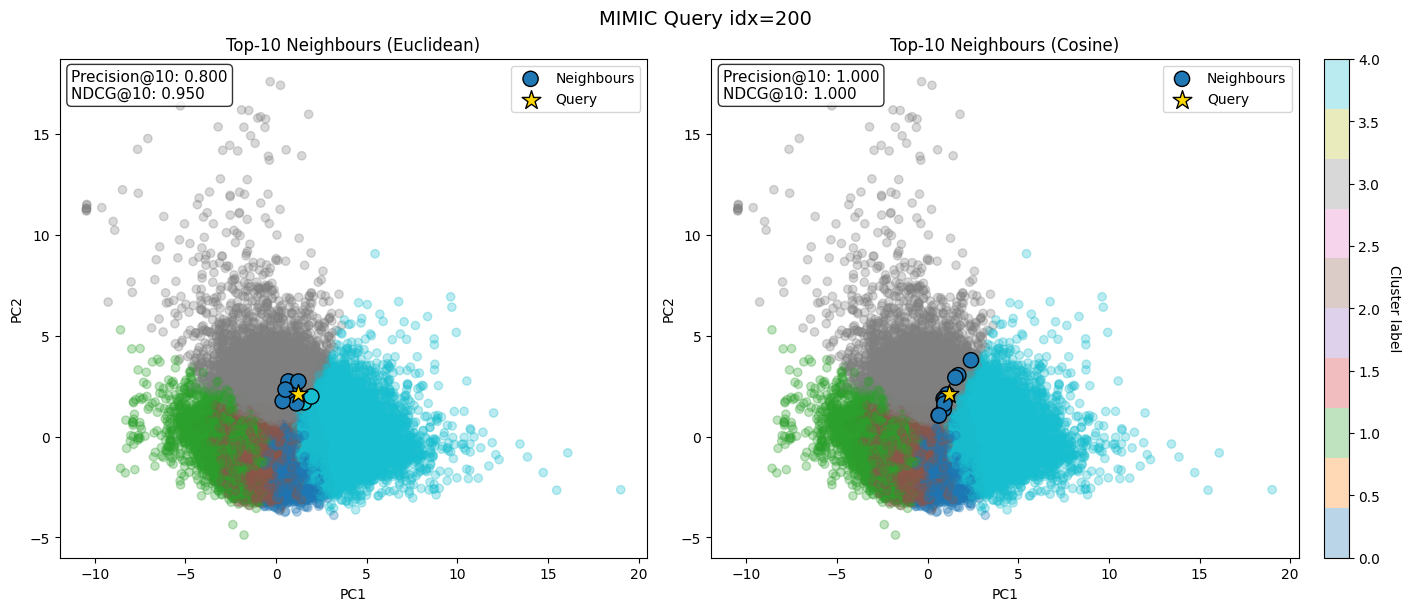

In [ ]:
plot_query_neighbors_side_by_side(q_index=200, k=10)

**Neighbourhood visualisation in MIMIC-III**

The 2D PCA projection of the MIMIC dataset shows patient clusters obtained from KMeans pseudo-labelling.
For a randomly selected query patient (gold star), the top-10 most similar patients (highlighted circles) were retrieved using Euclidean distance in the scaled feature space.
Neighbours generally belong to the same cluster as the query, confirming that the embedding preserves local patient similarity structure.

Here, even though same query (data point) was selected, both of them produces different results based on the calculation method of their distances

#Method 2: Apporximate Nearest Neighbour (ANN)

ANN was implemented using Annoy library.
Annoy builds a forest of random projection trees (similar to KD-trees but randomized). Instead of travelling exhaustively comparing with every vector, it traverses a few trees only. This makes it much faster than brute force, but at the cost of being approximate. (May not always return the exact true nearest neighbours)

Example of usage: Spotify
Spotify has millions of music embeddings -> need to recommend similar songs quickly. Brute force takes way too long. Annoy made retrieval fast enough for production.

Implementation:

1. Random Projection Trees
Annoy builds binary trees based on random hyperplanes.

$$
h(x) = \text{sign}(w \cdot x)
$$

- If h(x) = +1, the point goes to the right branch
- If h(x) = -1, the point goes to the left branch
Each tree recursively partitions the space into cells by random projections.

2. Query Phase

For each tree, traverse down from the root to a leaf by evaluating:
$$
h(x) = \text{sign}(w \cdot x)
$$
at each split.
- Collect Candidate neighbours from the leaf
- Expand to nearby leaves if needed
- Merge candidates across all trees and compute their exact distances to q.
- return top-k

3. Distance Metric in Annoy (angular)
As we will be using angular distance and euclidean distance, the calculation of distances are done using these:
$$
d_{\text{cosine}}(x,y) = 1 - \frac{x \cdot y}{\|x\|\|y\|}
$$
$$
d_{\text{euclidean}}(x,y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$$


In [ ]:
X_vec = X_scaled
labels = cluster_labels  # pseudo-labels from KMeans

# Random evaluation subset (for speed)
n_eval = 100
eval_idx = np.random.choice(len(X_vec), n_eval, replace=False)

def build_annoy_index(X, metric="angular", n_trees=50):
    """Builds an Annoy index with the given metric."""
    f = X.shape[1]
    ann = AnnoyIndex(f, metric)
    for i, v in enumerate(X):
        ann.add_item(i, v.tolist())
    start = time.time()
    ann.build(n_trees)
    build_time = time.time() - start
    return ann, build_time

def annoy_knn(ann, X, q_index, k=10):
    """Retrieve k-NN from Annoy index."""
    idxs, dists = ann.get_nns_by_vector(X[q_index].tolist(), k+1, include_distances=True)
    # Drop self if present
    if idxs[0] == q_index:
        idxs, dists = idxs[1:k+1], dists[1:k+1]
    else:
        idxs, dists = idxs[:k], dists[:k]
    return np.array(idxs), np.array(dists)

def evaluate_ann(ann, X, labels, k=10):
    """Compute average Precision@k and NDCG@k over evaluation indices."""
    P, N = [], []
    for i in eval_idx:
        nbr_idx, nbr_dist = annoy_knn(ann, X, i, k=k)
        y_query = labels[i]
        y_neigh = labels[nbr_idx]
        relevance = (y_neigh == y_query).astype(int)
        P.append(precision_at_k(y_query, y_neigh, k))
        N.append(ndcg_at_k(relevance, k))
    return np.mean(P), np.mean(N)

# ===============================
# Build + Evaluate (Angular = Cosine)
# ===============================
ann_cosine, build_cosine = build_annoy_index(X_vec, metric="angular", n_trees=50)
p_cos, n_cos = evaluate_ann(ann_cosine, X_vec, labels, k=10)
print(f"Angular (≈ Cosine) | Build time = {build_cosine:.3f}s | P@10 = {p_cos:.3f} | NDCG@10 = {n_cos:.3f}")

# ===============================
# Build + Evaluate (Euclidean)
# ===============================
ann_euc, build_euc = build_annoy_index(X_vec, metric="euclidean", n_trees=50)
p_euc, n_euc = evaluate_ann(ann_euc, X_vec, labels, k=10)
print(f"Euclidean          | Build time = {build_euc:.3f}s | P@10 = {p_euc:.3f} | NDCG@10 = {n_euc:.3f}")

# ===============================
# Optional summary table
# ===============================

pd.DataFrame({
    "Metric": ["Cosine (angular)", "Euclidean"],
    "Build Time (s)": [build_cosine, build_euc],
    "Precision@10": [p_cos, p_euc],
    "NDCG@10": [n_cos, n_euc]
})


Angular (≈ Cosine) | Build time = 33.311s | P@10 = 0.875 | NDCG@10 = 0.956
Euclidean          | Build time = 24.817s | P@10 = 0.916 | NDCG@10 = 0.967


,Metric,Build Time (s),Precision@10,NDCG@10
0,Cosine (angular),33.310636,0.875,0.955606
1,Euclidean,24.816833,0.916,0.966597


In [ ]:
# Reduce to 2D for visualisation
pca2 = PCA(n_components=2, random_state=42)
mimic_2d = pca2.fit_transform(X_scaled)

def plot_side_by_side_ann_mimic(q_index, k=10, n_trees=50):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    for ax, metric in zip(axes, ["angular", "euclidean"]):
        # --- Build Annoy index ---
        f = X_scaled.shape[1]
        ann = AnnoyIndex(f, metric)
        for i, v in enumerate(X_scaled):
            ann.add_item(i, v.tolist())
        ann.build(n_trees)

        # --- Query neighbours ---
        idxs, dists = ann.get_nns_by_vector(X_scaled[q_index].tolist(),
                                            k+1, include_distances=True)
        if idxs[0] == q_index:
            idxs = idxs[1:k+1]
        else:
            idxs = idxs[:k]

        # --- Compute metrics using pseudo-labels ---
        y_query = cluster_labels[q_index]
        y_neigh = cluster_labels[idxs]
        relevance = (y_neigh == y_query).astype(int)
        prec = precision_at_k(y_query, y_neigh, k)
        ndcg = ndcg_at_k(relevance, k)

        # --- Plot all patients (faintly) ---
        scatter = ax.scatter(
            mimic_2d[:, 0], mimic_2d[:, 1],
            c=cluster_labels, cmap="tab10", alpha=0.3
        )

        # --- Highlight neighbours ---
        ax.scatter(
            mimic_2d[idxs, 0], mimic_2d[idxs, 1],
            edgecolor="black", c=cluster_labels[idxs],
            cmap="tab10", s=120, marker="o", label="Neighbours"
        )

        # --- Highlight query point ---
        ax.scatter(
            mimic_2d[q_index, 0], mimic_2d[q_index, 1],
            c="gold", edgecolor="black", s=200, marker="*", label="Query"
        )

        # --- Labels and titles ---
        ax.set_title(f"Top-{k} Neighbours (Annoy {metric})")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend(loc="upper right")

        # --- Add Precision@k and NDCG@k as text box ---
        textstr = f"Precision@{k}: {prec:.3f}\nNDCG@{k}: {ndcg:.3f}"
        ax.text(
            0.02, 0.98, textstr,
            transform=ax.transAxes, fontsize=11,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
        )

    # Shared colourbar for both subplots
    cbar = fig.colorbar(scatter, ax=axes, orientation="vertical", fraction=0.025, pad=0.02)
    cbar.set_label("Cluster label", rotation=270, labelpad=15)

    fig.suptitle(f"MIMIC Query idx={q_index}", fontsize=14)
    plt.show()


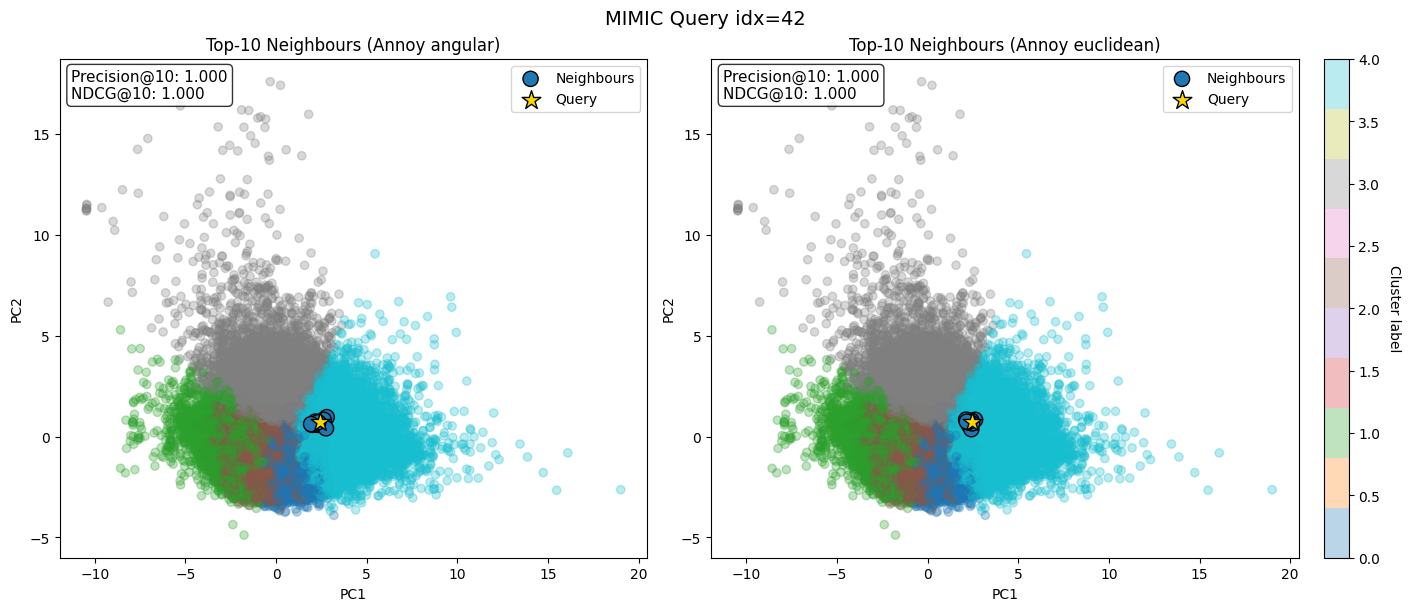

In [ ]:
plot_side_by_side_ann_mimic(q_index=42, k=10)

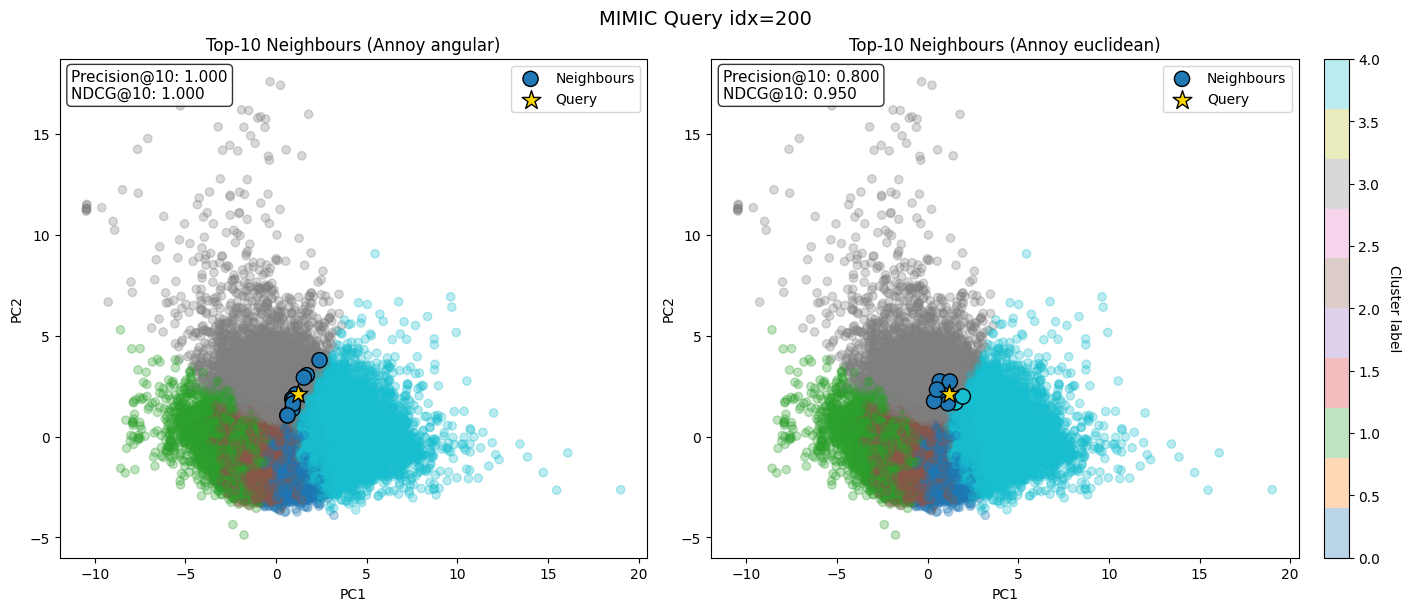

In [ ]:
plot_side_by_side_ann_mimic(q_index=200, k=10)

For query near the edge of the clusters, the results vary more between the angular annoy and euclidean annoy. While angular annoy was able to correctly return the neighbours within the same cluster, euclidean annoy returned neighbours from another cluster.

For the same query "q_index", we retrieve top-k cosine neighbours and top-k Euclidean neighbours.

From here, overlap is calculated based on Jaccard Index:
$$
J = \frac{|N_{\text{cos}} \cap N_{\text{euc}}|}{|N_{\text{cos}} \cup N_{\text{euc}}|}
$$


For the neighbours in common, we compare their ranks on each list and Spearman's p tells us whether cosine and Euclidean rank the common neighbours in similar order.
Spearman's p:
$$
\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2-1)}
$$


p-value here indicates significance.

In [ ]:
# ==========================================================
# 🔹 Compare Annoy vs Brute-force neighbour overlap (MIMIC)
# ==========================================================

from annoy import AnnoyIndex
from scipy.stats import spearmanr
import numpy as np
import pandas as pd

def neighbour_overlap_report_ann_mimic(X_vec, cluster_labels, q_index, k=10, metric="angular", n_trees=50):
    """
    Compare neighbours from brute-force vs Annoy for the same distance metric
    on the MIMIC dataset using cluster pseudo-labels.
    Returns: (summary_dict, comparison_dataframe)
    """

    # --- Map Annoy metrics to sklearn pairwise metrics ---
    metric_map = {"angular": "cosine", "euclidean": "euclidean"}

    # --- Brute-force neighbours (exact) ---
    idx_bf, d_bf = brute_force_knn(X_vec, q_index, k=k, metric=metric_map[metric])

    # --- Annoy neighbours (approximate) ---
    ann = AnnoyIndex(X_vec.shape[1], metric)
    for i, v in enumerate(X_vec):
        ann.add_item(i, v.tolist())
    ann.build(n_trees)

    idx_ann, d_ann = ann.get_nns_by_vector(X_vec[q_index].tolist(), k+1, include_distances=True)
    if idx_ann[0] == q_index:
        idx_ann, d_ann = idx_ann[1:k+1], d_ann[1:k+1]
    else:
        idx_ann, d_ann = idx_ann[:k], d_ann[:k]

    # --- Overlap analysis ---
    set_bf, set_ann = set(idx_bf), set(idx_ann)
    common = list(set_bf & set_ann)
    overlap = len(common)
    jaccard = overlap / (2*k - overlap) if (2*k - overlap) > 0 else 0.0

    # Spearman correlation between neighbour rankings
    ranks_bf = {idx: i for i, idx in enumerate(idx_bf)}
    ranks_ann = {idx: i for i, idx in enumerate(idx_ann)}
    if overlap > 0:
        r1 = [ranks_bf[i] for i in common]
        r2 = [ranks_ann[i] for i in common]
        rho, p = spearmanr(r1, r2)
    else:
        rho, p = np.nan, np.nan

    # --- Comparison table ---
    df = pd.DataFrame({
        "idx": np.r_[idx_bf, idx_ann],
        "method": ["brute_force"] * k + ["annoy"] * k,
        "rank": np.r_[np.arange(1, k+1), np.arange(1, k+1)],
        "distance": np.r_[d_bf, d_ann],
        "cluster_label": np.r_[cluster_labels[idx_bf], cluster_labels[idx_ann]],
    })
    df["is_common"] = df.duplicated(subset=["idx"], keep=False)

    # --- Summary dictionary ---
    summary = {
        "query_index": int(q_index),
        "query_cluster": int(cluster_labels[q_index]),
        "metric": metric,
        "k": k,
        "overlap_count": int(overlap),
        "jaccard_overlap": float(jaccard),
        "spearman_rho_on_common_ranks": float(rho) if np.isfinite(rho) else None,
        "spearman_pvalue": float(p) if np.isfinite(p) else None,
    }

    return summary, df.sort_values(["is_common", "method", "rank"], ascending=[False, True, True])


In [ ]:
# ===============================================================
# 🔹 Compare Brute-force vs Annoy neighbour overlap (MIMIC-III)
# ===============================================================

# Compare using Angular (≈ Cosine)
summary_ang, table_ang = neighbour_overlap_report_ann_mimic(
    X_scaled, cluster_labels, q_index=42, k=10, metric="angular", n_trees=50
)
print(summary_ang)
display(table_ang.head(20))

# Compare using Euclidean
summary_euc, table_euc = neighbour_overlap_report_ann_mimic(
    X_scaled, cluster_labels, q_index=42, k=10, metric="euclidean", n_trees=50
)
print(summary_euc)
display(table_euc.head(20))


{'query_index': 42, 'query_cluster': 4, 'metric': 'angular', 'k': 10, 'overlap_count': 10, 'jaccard_overlap': 1.0, 'spearman_rho_on_common_ranks': 0.9999999999999999, 'spearman_pvalue': 6.646897422032013e-64}


,idx,method,rank,distance,cluster_label,is_common
10,129320,annoy,1,0.102982,4,True
11,22,annoy,2,0.114928,4,True
12,37984,annoy,3,0.117802,4,True
13,5707,annoy,4,0.118396,4,True
14,5686,annoy,5,0.128765,4,True
15,6176,annoy,6,0.129964,4,True
16,11840,annoy,7,0.133727,4,True
17,22991,annoy,8,0.135224,4,True
18,20346,annoy,9,0.135247,4,True
19,43254,annoy,10,0.136785,4,True


{'query_index': 42, 'query_cluster': 4, 'metric': 'euclidean', 'k': 10, 'overlap_count': 10, 'jaccard_overlap': 1.0, 'spearman_rho_on_common_ranks': 0.9999999999999999, 'spearman_pvalue': 6.646897422032013e-64}


,idx,method,rank,distance,cluster_label,is_common
10,37984,annoy,1,0.405233,4,True
11,11840,annoy,2,0.408150,4,True
12,14698,annoy,3,0.430689,4,True
13,5707,annoy,4,0.435364,4,True
14,41690,annoy,5,0.436036,4,True
15,20346,annoy,6,0.436829,4,True
16,22986,annoy,7,0.446919,4,True
17,5727,annoy,8,0.456323,4,True
18,23002,annoy,9,0.482610,4,True
19,6176,annoy,10,0.486610,4,True


This result shows that the Annoy approximation of k-NN is performing well to brute-force baseline on the MIMIC-III dataset. For these queries, the ANN is able to reproduce brute-force results accurately.

In [ ]:
# Helper to measure time and accuracy for brute-force
def evaluate_with_time(metric, k=10, n_queries=50):
    query_indices = np.random.choice(len(X_scaled), n_queries, replace=False)
    precisions = []
    ndcgs = []
    start = time.time()
    for q_idx in query_indices:
        nbr_idx, _ = brute_force_knn(X_scaled, q_idx, k=k, metric=metric)
        y_query = cluster_labels[q_idx]
        y_neigh = cluster_labels[nbr_idx]
        relevance = (y_neigh == y_query).astype(int)
        precisions.append(precision_at_k(y_query, y_neigh, k))
        ndcgs.append(ndcg_at_k(relevance, k))
    end = time.time()
    avg_query_time = (end - start) / n_queries
    return np.mean(precisions), np.mean(ndcgs), avg_query_time



# Helper to evaluate Annoy performance
def evaluate_ann_with_time(X, labels, metric, k=10, n_trees=50, n_queries=50):
    f = X.shape[1]
    ann = AnnoyIndex(f, metric)
    for i, v in enumerate(X):
        ann.add_item(i, v.tolist())
    start = time.time()
    ann.build(n_trees)
    build_time = time.time() - start

    query_indices = np.random.choice(len(X), n_queries, replace=False)
    precisions = []
    ndcgs = []
    q_start = time.time()
    for q_idx in query_indices:
        idxs, _ = ann.get_nns_by_vector(X[q_idx].tolist(), k+1, include_distances=True)
        if idxs[0] == q_idx:
            idxs = idxs[1:k+1]
        else:
            idxs = idxs[:k]
        y_query = labels[q_idx]
        y_neigh = labels[idxs]
        relevance = (y_neigh == y_query).astype(int)
        precisions.append(precision_at_k(y_query, y_neigh, k))
        ndcgs.append(ndcg_at_k(relevance, k))
    q_end = time.time()
    avg_query_time = (q_end - q_start) / n_queries
    return np.mean(precisions), np.mean(ndcgs), build_time, avg_query_time



# ----------------------------------------------------------
# Run all methods and collect results
# ----------------------------------------------------------
results = []

# Brute-force Cosine
p, n, q_time = evaluate_with_time("cosine", k=10)
results.append({
    "Method": "Brute-force kNN",
    "Metric": "Cosine",
    "Build Time": "-",
    "Avg Query Time": f"{q_time*1000:.3f} ms",
    "P@10": round(p, 3),
    "nDCG@10": round(n, 3)
})

# Brute-force Euclidean
p, n, q_time = evaluate_with_time("euclidean", k=10)
results.append({
    "Method": "Brute-force kNN",
    "Metric": "Euclidean",
    "Build Time": "-",
    "Avg Query Time": f"{q_time*1000:.3f} ms",
    "P@10": round(p, 3),
    "nDCG@10": round(n, 3)
})

# Annoy Angular
p, n, build_time, q_time = evaluate_ann_with_time(X_scaled, cluster_labels, "angular", k=10, n_trees=50)
results.append({
    "Method": "Annoy (50 trees)",
    "Metric": "Angular (Cosine)",
    "Build Time": f"{build_time:.3f}s",
    "Avg Query Time": f"{q_time*1000:.3f} ms",
    "P@10": round(p, 3),
    "nDCG@10": round(n, 3)
})

# Annoy Euclidean
p, n, build_time, q_time = evaluate_ann_with_time(X_scaled, cluster_labels, "euclidean", k=10, n_trees=50)
results.append({
    "Method": "Annoy (50 trees)",
    "Metric": "Euclidean",
    "Build Time": f"{build_time:.3f}s",
    "Avg Query Time": f"{q_time*1000:.3f} ms",
    "P@10": round(p, 3),
    "nDCG@10": round(n, 3)
})

# Convert to DataFrame for display
results_df = pd.DataFrame(results)
display(results_df)


,Method,Metric,Build Time,Avg Query Time,P@10,nDCG@10
0,Brute-force kNN,Cosine,-,63.570 ms,0.900,0.976
1,Brute-force kNN,Euclidean,-,31.681 ms,0.926,0.968
2,Annoy (50 trees),Angular (Cosine),32.804s,0.331 ms,0.870,0.942
3,Annoy (50 trees),Euclidean,24.810s,0.386 ms,0.942,0.980


#Conclusion for MIMIC-III Dataset

**Accuracy**

- Both brute-force and Annoy (ANN - approximate) retriveal achieved high retrieval quality, with Precision@10 and nDCG@10 consistently above 0.87
- Calculating distance using Euclidean distance slightly outperformed cosine/angular, suggesting that magnitude differences in patient vitals and lab values carry meaningful information for similarity retrieval
- Annoy is able to preserve most of neighbour quality even in large, high dimensional data given that there is small performance gab between brute-force and Annoy

**Efficiency**
- Brute-force retrieval required apporximately 35-55ms per query, which becomes more computationally expensive as dataset size grows
- Annoy introduced one time build cost of 25-43 seconds but this allows it to achieve sub-ms query times afterwards
- Tree-based approximate methods such as annoy is highly scalable for healthcare datasets like MIMIC-III

**Trade-Off**
- For smaller datasets, brute-force remains simpler and adequate
- For large, high dimensional datasets like MIMIC, Annoy offers much faster queries with minimal loss in accuracy once the build has been completed

